# Fase 3: Recommendations engine

Demonstração do `KlikeEngine` com:
1. Recomendações para uma campanha específica
2. Comparação de recomendações por plataforma
3. Análise em lote 

In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from engine import KlikeEngine

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../Fase 1/klike_challenge_dataset_pt.csv', parse_dates=['data'])
engine = KlikeEngine(df)
print(f"Engine inicializado com {len(df)} campanhas históricas.")
print(f"Plataformas: {sorted(df['plataforma'].unique())}")

Engine inicializado com 500 campanhas históricas.
Plataformas: ['LinkedIn', 'Meta', 'TikTok']


## 1. Campanha individual com as recomendações detalhadas

Foi pefo uma campanha com Klike Score abaixo da mediana para ver o que o engine sugere

In [5]:
# Campanha com  boa candidatura para melhorias
mediana = df['pontuacao_klike'].median()
candidatas = df[df['pontuacao_klike'] < mediana].sample(1, random_state=7)
campanha = candidatas.iloc[0]

print("CAMPANHA ANALISADA:")
campos = ['id_campanha','plataforma','categoria','objetivo','pontuacao_klike',
          'tem_hook','tem_rosto','tem_cta','tem_legenda','densidade_texto',
          'formato','duracao_video_s','e_retargeting']
for campo in campos:
    print(f"  {campo:<30}: {campanha.get(campo, 'N/A')}")
print()
print(engine.relatorio(campanha, top_n=5))

CAMPANHA ANALISADA:
  id_campanha                   : KLK-0308
  plataforma                    : Meta
  categoria                     : Lead Gen
  objetivo                      : conversions
  pontuacao_klike               : 43.9
  tem_hook                      : False
  tem_rosto                     : True
  tem_cta                       : False
  tem_legenda                   : False
  densidade_texto               : low
  formato                       : vertical
  duracao_video_s               : 26.0
  e_retargeting                 : False

════════════════════════════════════════════════════════════════════
  RELATÓRIO DE RECOMENDAÇÕES
  Campanha : KLK-0308  |  Plataforma: Meta
  Klike Score atual : 43.9  |  Mediana Meta: 60.5
════════════════════════════════════════════════════════════════════

  [1] Adicionar hook nos primeiros 3 segundos
      Impacto estimado  : ~+18 pts Klike Score
      Métricas afetadas : Klike Score (+18 pts), CTR (+57%)
      Confiança         : ●●● alta
 

## 2. Mesma campanha em 3 plataformas diferentes

In [7]:
# Simulação de como seriam as recomendações em cada plataforma
# ilustrando como o engine é contextual e suas recomendações mudam de acordo com a plataforma

base = df[df['tem_hook'] == 0].iloc[0].copy()  # campanha sem hook
for plat in ['TikTok', 'Meta', 'LinkedIn']:
    campanha_plat = base.copy()
    campanha_plat['plataforma'] = plat
    recs = engine.recomendar(campanha_plat, top_n=3)
    print(f" \nPlataforma: {plat}")
    print(f"\n")
    for i, r in enumerate(recs, 1):
        print(f"  [{i}] {r.titulo}")
        print(f"      Impacto: ~+{r.impacto_klike:.0f} pts | Confiança: {r.confianca}")
        print(f"      {r.descricao[:120]}...")

 
Plataforma: TikTok


  [1] Adicionar hook nos primeiros 3 segundos
      Impacto: ~+17 pts | Confiança: alta
      Campanhas com hook no TikTok têm CTR ~3.5pp maior (79% de aumento relativo) e Klike Score ~17 pts mais alto (de 54 → 71)...
  [2] Testar versão com retargeting para audiência quente
      Impacto: ~+4 pts | Confiança: media
      No TikTok, campanhas de retargeting têm ROAS ~5.50 vs. ~2.19 em audiência nova (+152%) e CTR ~10.0% vs. ~4.8% (+110%). U...
 
Plataforma: Meta


  [1] Adicionar hook nos primeiros 3 segundos
      Impacto: ~+18 pts | Confiança: alta
      Campanhas com hook no Meta têm CTR ~2.8pp maior (57% de aumento relativo) e Klike Score ~18 pts mais alto (de 52 → 70). ...
  [2] Testar versão com retargeting para audiência quente
      Impacto: ~+0 pts | Confiança: media
      No Meta, campanhas de retargeting têm ROAS ~1.92 vs. ~1.55 em audiência nova (+24%) e CTR ~9.3% vs. ~5.7% (+64%). Usuári...
 
Plataforma: LinkedIn


  [1] Adicionar hook nos primeiros 

## 3. Análise em lote com potencial de melhoria por plataforma

In [9]:
# Para cada campanha, calcula o ganho potencial total das recomendações top-3
# respondendo a pergunta: em qual plataforma há mais oportunidades de otimização?

resultados_bulk = []
for _, row in df.iterrows():
    recs  = engine.recomendar(row, top_n=3)
    ganho = sum(r.impacto_klike for r in recs)
    n_rec = len(recs)
    resultados_bulk.append({
        'id_campanha':     row['id_campanha'],
        'plataforma':      row['plataforma'],
        'klike_atual':     row['pontuacao_klike'],
        'ganho_potencial': ganho,
        'n_recomendacoes': n_rec,
    })

bulk_df = pd.DataFrame(resultados_bulk)
print("Estatísticas gerais do ganho potencial (top-3 recomendações por campanha):")
print("\n")
print(bulk_df.groupby('plataforma')[['ganho_potencial','n_recomendacoes']].describe().round(1))

Estatísticas gerais do ganho potencial (top-3 recomendações por campanha):


           ganho_potencial                                           \
                     count  mean   std  min   25%   50%   75%   max   
plataforma                                                            
LinkedIn              83.0  28.5   7.8  9.6  24.4  29.5  33.5  52.7   
Meta                 241.0  26.9  12.3  0.0  18.2  28.4  36.5  50.7   
TikTok               176.0  27.3   8.9  0.0  20.8  28.9  34.3  42.6   

           n_recomendacoes                                     
                     count mean  std  min  25%  50%  75%  max  
plataforma                                                     
LinkedIn              83.0  2.9  0.3  2.0  3.0  3.0  3.0  3.0  
Meta                 241.0  2.8  0.5  0.0  3.0  3.0  3.0  3.0  
TikTok               176.0  2.8  0.4  0.0  3.0  3.0  3.0  3.0  


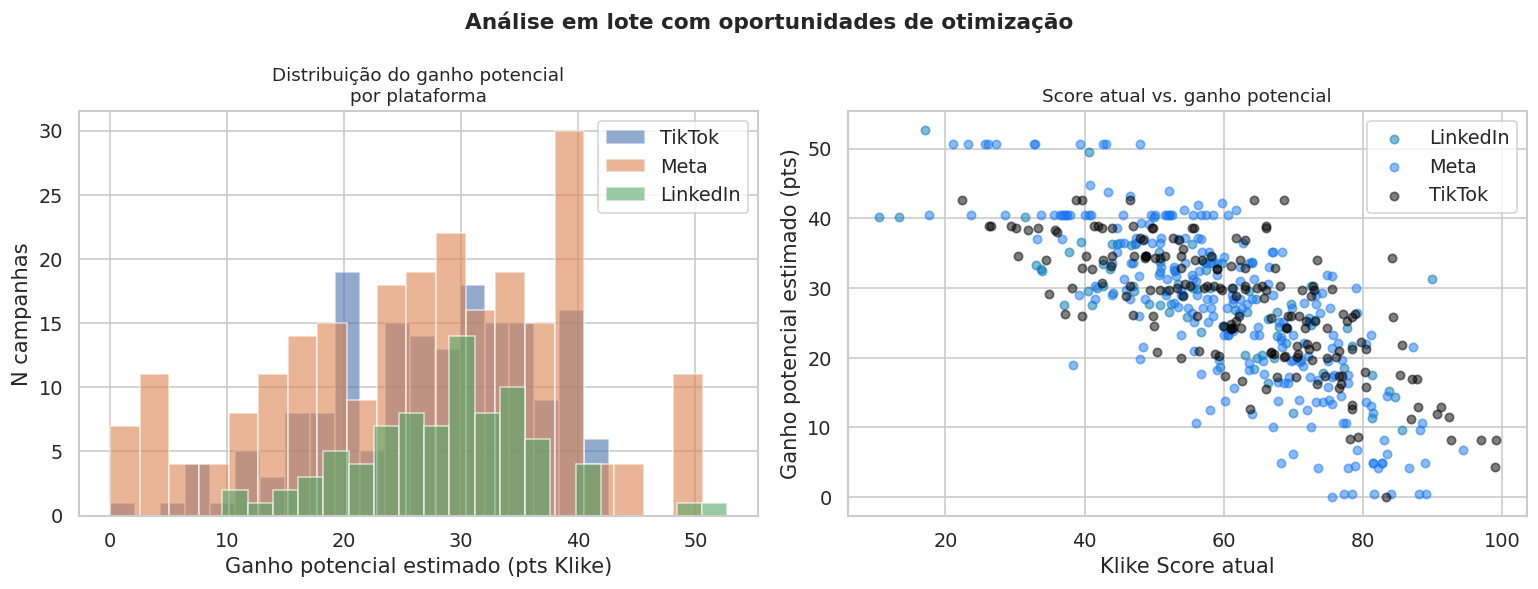

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for plat in ['TikTok', 'Meta', 'LinkedIn']:
    sub = bulk_df[bulk_df['plataforma'] == plat]['ganho_potencial']
    ax.hist(sub, bins=20, alpha=0.6, label=plat)
ax.set_xlabel('Ganho potencial estimado (pts Klike)')
ax.set_ylabel('N campanhas')
ax.set_title('Distribuição do ganho potencial\npor plataforma', fontsize=11)
ax.legend()

ax2 = axes[1]
cores = {'TikTok': '#010101', 'Meta': '#1877F2', 'LinkedIn': '#0077B5'}
for plat, sub in bulk_df.groupby('plataforma'):
    ax2.scatter(sub['klike_atual'], sub['ganho_potencial'],
                alpha=0.5, s=25, label=plat, color=cores[plat])
ax2.set_xlabel('Klike Score atual')
ax2.set_ylabel('Ganho potencial estimado (pts)')
ax2.set_title('Score atual vs. ganho potencial', fontsize=11)
ax2.legend()

plt.suptitle('Análise em lote com oportunidades de otimização', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Oportunidades para campanhas com maior potencial de melhoria

In [12]:
# Quais campanhas têm maior potencial de ganho e ainda estão com score baixo?
oportunidades = bulk_df[bulk_df['n_recomendacoes'] > 0].sort_values(
    'ganho_potencial', ascending=False
).head(10)

print("Campanhas com maior potencial de melhoria:")
print(oportunidades[['id_campanha','plataforma','klike_atual',
                       'ganho_potencial','n_recomendacoes']].to_string(index=False))

Campanhas com maior potencial de melhoria:
id_campanha plataforma  klike_atual  ganho_potencial  n_recomendacoes
   KLK-0442   LinkedIn         17.1            52.70                3
   KLK-0450       Meta         32.8            50.65                3
   KLK-0169       Meta         39.4            50.65                3
   KLK-0282       Meta         21.1            50.65                3
   KLK-0203       Meta         42.6            50.65                3
   KLK-0181       Meta         27.3            50.65                3
   KLK-0336       Meta         48.0            50.65                3
   KLK-0342       Meta         25.7            50.65                3
   KLK-0024       Meta         43.1            50.65                3
   KLK-0466       Meta         23.3            50.65                3


## 5. Simulação de impacto de adicionar hook em todas as campanhas sem ele

In [13]:
sem_hook = df[df['tem_hook'].map({'True':False,'False':True,True:False,False:True,0:True,1:False}) == True]

ganhos_hook = []
for _, row in sem_hook.iterrows():
    plat = row['plataforma']
    bm   = engine._bm.get(plat, {})
    dk   = bm.get('tem_hook_delta_klike', 0)
    ganhos_hook.append({'plataforma': plat, 'ganho_hook': dk})

gh_df = pd.DataFrame(ganhos_hook)

print(f"Campanhas sem hook: {len(sem_hook)} ({len(sem_hook)/len(df)*100:.0f}% do total)")
print()
print("Ganho estimado médio ao adicionar hook, por plataforma:")
print(gh_df.groupby('plataforma')['ganho_hook'].mean().round(1))
print()
print(f"Ganho médio global: {gh_df['ganho_hook'].mean():.1f} pts de Klike Score")

Campanhas sem hook: 244 (49% do total)

Ganho estimado médio ao adicionar hook, por plataforma:
plataforma
LinkedIn    13.7
Meta        17.7
TikTok      17.0
Name: ganho_hook, dtype: float64

Ganho médio global: 16.8 pts de Klike Score


In [14]:
print('Dados consolidados: ')
print("\n")
print(f"Dataset de benchmark : {len(df)} campanhas históricas")
print(f"Plataformas cobertas : {', '.join(sorted(df['plataforma'].unique()))}")
print(f"Regras implementadas : 9 (hook, rosto, CTA, legenda, texto,")
print(f"                             formato, duração, retargeting, áudio)")
print()
print(f"Campanhas com ≥1 recomendação: {(bulk_df['n_recomendacoes']>0).sum()} ({(bulk_df['n_recomendacoes']>0).mean()*100:.0f}%)")
print(f"Ganho potencial médio (top-3) : {bulk_df['ganho_potencial'].mean():.1f} pts")
print(f"Campanha com maior potencial  : {oportunidades.iloc[0]['id_campanha']} (+{oportunidades.iloc[0]['ganho_potencial']:.0f} pts)")

Dados consolidados: 


Dataset de benchmark : 500 campanhas históricas
Plataformas cobertas : LinkedIn, Meta, TikTok
Regras implementadas : 9 (hook, rosto, CTA, legenda, texto,
                             formato, duração, retargeting, áudio)

Campanhas com ≥1 recomendação: 498 (100%)
Ganho potencial médio (top-3) : 27.3 pts
Campanha com maior potencial  : KLK-0442 (+53 pts)
